In [27]:
from matplotlib import pyplot as plt
from datasets import load_dataset

In [28]:
# 1. Stream and take your subset
streamed = load_dataset("saberzl/SID_Set", split="train", streaming=True)
first_100 = list(streamed.take(100))

In [36]:
# 2. Convert back to Dataset and save efficiently
import os
from datasets import Dataset
dataset = Dataset.from_list(first_100)

dir = "data"
dataset_name = "SID_saved"
dataset_dir = os.path.join(dir, dataset_name)

# 3. Save to disk for later use only if not already saved by checking if there is already a folder named data
if dataset_name not in os.listdir("data"):
    print("Saving dataset to disk...")
    dataset.save_to_disk(dataset_dir)


In [38]:
# 3. Later, load it back instantly
from datasets import load_from_disk
loaded_dataset = load_from_disk(dataset_dir)

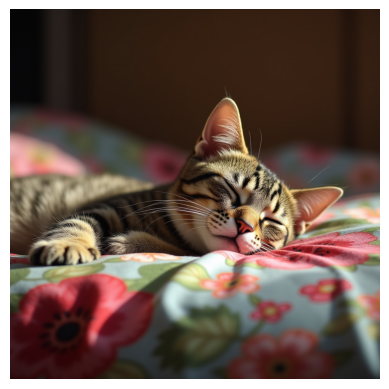

In [39]:
# 4. Show a save image from loaded dataset
img = loaded_dataset[0]["image"]
plt.imshow(img)
plt.axis('off')
plt.show()

In [40]:
# 5. Inspecting the dataset format and schema

# Print a summary of the dataset object
print(dataset)
# Print the current format settings (should be None before setting)
print("Current format:", dataset.format)

# Inspect the column names and feature types
print("Columns:", dataset.column_names)
print("Features:", dataset.features)

Dataset({
    features: ['img_id', 'image', 'mask', 'width', 'height', 'label'],
    num_rows: 100
})
Current format: {'type': None, 'format_kwargs': {}, 'columns': ['img_id', 'image', 'mask', 'width', 'height', 'label'], 'output_all_columns': False}
Columns: ['img_id', 'image', 'mask', 'width', 'height', 'label']
Features: {'img_id': Value('string'), 'image': Image(mode=None, decode=True), 'mask': Image(mode=None, decode=True), 'width': Value('int64'), 'height': Value('int64'), 'label': Value('int64')}


In [ ]:
from torchvision.transforms import Compose, Resize, ToTensor, Grayscale, Lambda
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image

# 1. Create a transform pipeline
image_transform = Compose([
    # Force convert any image to RGB (3 channels)
    Resize((256, 256)), # resize to fixed size
    Lambda(lambda img: img.convert("RGB") if isinstance(img, Image.Image) else img), # Some of the images are grayscale
    ToTensor()   # now always yields shape (3,256,256)
])

mask_transform = Compose([
    Resize((256, 256)),
    Grayscale(num_output_channels=1),  # force 1 channel
    ToTensor()                         # yields shape (1,256,256)
])

class HFDataset(Dataset):
    def __init__(self, hf_ds, device=None):
        self.ds = hf_ds
        self.device = device

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        ex = self.ds[idx]

        # Transform image
        img = image_transform(ex["image"])  # → tensor shape (3,256,256)
        #print(f"Image shape: {img.shape}, Type: {type(img)}, Dtype: {img.dtype}, Min: {img.min().item()}, Max: {img.max().item()}")

        # Transform mask if present
        if ex["mask"] is not None:
            mask = mask_transform(ex["mask"])
        else:
            mask = torch.zeros((1,256,256), dtype=torch.float)
        #print(f"Mask shape: {mask.shape}, Type: {type(mask)}, Dtype: {mask.dtype}, Min: {mask.min().item()}, Max: {mask.max().item()}")

        label = torch.tensor(ex["label"], dtype=torch.long)
        #print(f"Label: {label}, Type: {type(label)}, Value: {label.item()}")

        if self.device:
            img, mask, label = img.to(self.device), mask.to(self.device), label.to(self.device)
        return {"image": img, "mask": mask, "label": label}

hf_ds = load_from_disk("data/SID_saved")
device = torch.device("cuda") if torch.cuda.is_available() else None
wrapped = HFDataset(hf_ds, device=device)

loader = DataLoader(
    wrapped,
    batch_size=20,
    shuffle=True,
    num_workers=0,     # adjust based on your CPU cores
    pin_memory=bool(device)
)
batch = next(iter(loader))
print(f"Batch of images: {batch['image'].shape}, Batch of masks: {batch['mask'].shape}, Batch of labels: {batch['label'].shape}")


batch = next(iter(loader))
print(f"Batch of images: {batch['image'].shape}")  # → (batch_size,3,256,256)
print(f"Batch of masks: {batch['mask'].shape}")   # → (batch_size,1,256,256)


Batch of images: torch.Size([20, 3, 256, 256]), Batch of masks: torch.Size([20, 1, 256, 256]), Batch of labels: torch.Size([20])
Batch of images: torch.Size([20, 3, 256, 256])
Batch of masks: torch.Size([20, 1, 256, 256])


In [ ]:
# 6. Use the data with torch
from torch.utils.data import DataLoader
from torch import cuda
import numpy as np

def to_numpy(example):
    example["image"] = np.array(example["image"])   # H×W×3 uint8
    # If some masks are None, handle that:
    if example["mask"] is not None:
        example["mask"] = np.array(example["mask"]) # H×W×3 uint8 (or single‐channel)
    return example

dataset = dataset.map(to_numpy, remove_columns=[])

# 4. Now set format to torch for only the tensor fields
format_kwargs = {"type": "torch", "columns": ["image", "mask", "label"]}
if cuda.is_available():
    format_kwargs["device"] = "cuda"
dataset.set_format(**format_kwargs)

# 5. Create your DataLoader
dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=cuda.is_available()
)

# 6. Verify shapes on one batch
batch = next(iter(dataloader))
print("Images:", batch["image"].shape)  # (32, 1024, 1024, 3) on CPU or (32,1024,1024,3) on GPU
print("Masks: ", batch["mask"].shape)   # (32, 1024, 1024, 3) or possibly (32,1024,1024,3)
print("Labels:", batch["label"].shape)  # (32,)

# If you prefer channel‐first (C×H×W), simply transpose before saving:
# In to_numpy: example["image"] = np.array(example["image"]).transpose(2,0,1)

Map:   0%|          | 0/100 [00:00<?, ? examples/s]C:\Users\Bjark\AppData\Local\Temp\ipykernel_36884\337993158.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  example["image"] = np.array(example["image"])   # H×W×3 uint8
Map:   2%|▏         | 2/100 [00:00<00:08, 12.16 examples/s]C:\Users\Bjark\AppData\Local\Temp\ipykernel_36884\337993158.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  example["mask"] = np.array(example["mask"]) # H×W×3 uint8 (or single‐channel)
Map

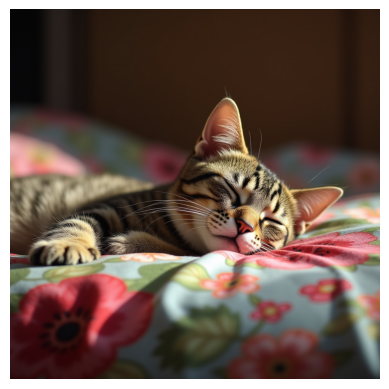

<PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024 at 0x2397FDC6060>


In [62]:
img = loaded_dataset[0]["image"]
plt.imshow(img)
plt.axis('off')
plt.show()
print(img)  # (H,W,3)


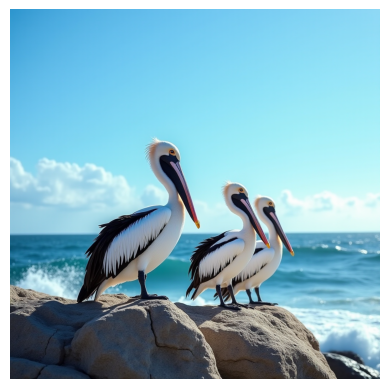

<PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024 at 0x23953DE2510>


In [ ]:
img = loaded_dataset[2]["image"]
plt.imshow(img)
plt.axis('off')
plt.show()
print(img)  # (H,W,3)